# TetheredAI MLB Model Diagnostics + Logit Benchmark

This notebook is designed to answer the question: **is the model actually better than simple MLB baselines?**

It does four things:

1. Builds clear benchmark rows: home-rate baseline, always-home classification, and Elo-only probability if available.
2. Separates feature groups so you can see whether the signal comes from team form, Elo, starters, bullpen, or enhanced features.
3. Adds a true **logit / logistic regression** model alongside tree, boosting, and optional SVM models.
4. Provides calibration, feature-importance, edge-tuning, and manual champion-model export cells.

Expected project layout:

```text
MLB/mlb_betting_app/
  data/processed/mlb_game_features.parquet
  data/predictions/mlb_moneyline_predictions.csv
  models/
  notebooks/
  src/mlb_betting/
```

## 0. Configuration

Start conservative. Use the fast model list first, then widen after the notebook is working.

- `MODEL_NAMES = None` runs all available model candidates.
- To save time, set `MODEL_NAMES` to a smaller list.
- `RUN_SVM = False` by default because SVM with probability calibration can be slow.

In [1]:
from pathlib import Path
import sys
import json
import warnings
from datetime import datetime, timezone

PROJECT_ROOT_CANDIDATES = []
cwd = Path.cwd().resolve()
PROJECT_ROOT_CANDIDATES.extend([cwd, *cwd.parents])

PROJECT_ROOT = None
for p in PROJECT_ROOT_CANDIDATES:
    if (p / "data").exists() and (p / "src").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    # If running from notebooks/, parent should be project root.
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

SRC_PATH = PROJECT_ROOT / "src"
if SRC_PATH.exists() and str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PREDICTIONS_DIR = DATA_DIR / "predictions"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH = PROCESSED_DIR / "mlb_game_features.parquet"
PREDICTION_PATH = PREDICTIONS_DIR / "mlb_moneyline_predictions.csv"
DB_PATH = DATA_DIR / "odds.db"

# Modeling controls
HOLDOUT_N = 800                  # keep comparable to your prior result
MIN_FEATURE_NON_NULL_RATE = 0.05 # exclude columns that are nearly always null
RUN_FULL_SEARCH = False          # False = smaller/faster grids
RUN_SVM = False                  # SVM can be slow with probability=True
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_IMPORTANCE_REPEATS = 5
RANDOM_STATE = 42
CV_SPLITS = 3
N_ITER_RANDOM_SEARCH = 20

# Use None for all available models, or set a list.
MODEL_NAMES = [
    "logit_l2",
    "random_forest",
    "extra_trees",
    "hist_gradient_boosting",
    "xgboost",
    "lightgbm",
]
# Example slow run:
# MODEL_NAMES = None
# RUN_SVM = True

# Use None for all feature sets, or set a list.
FEATURE_SET_NAMES = None

print("Project root:", PROJECT_ROOT)
print("Feature path:", FEATURE_PATH)
print("Predictions path:", PREDICTION_PATH)
print("Model dir:", MODEL_DIR)

Project root: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app
Feature path: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet
Predictions path: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\predictions\mlb_moneyline_predictions.csv
Model dir: C:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\models


## 1. Imports

XGBoost and LightGBM are optional. If they are not installed, the notebook will skip those model families.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as e:
    HAS_XGBOOST = False
    XGBClassifier = None
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception as e:
    HAS_LIGHTGBM = False
    LGBMClassifier = None
    print("LightGBM unavailable:", e)

warnings.filterwarnings("ignore", category=UserWarning)
print("HAS_XGBOOST:", HAS_XGBOOST)
print("HAS_LIGHTGBM:", HAS_LIGHTGBM)

HAS_XGBOOST: True
HAS_LIGHTGBM: True


## 2. Load feature data

This reads the committed output from your full feature refresh workflow.

In [3]:
if not FEATURE_PATH.exists():
    raise FileNotFoundError(f"Feature file not found: {FEATURE_PATH}")

features = pd.read_parquet(FEATURE_PATH)
print("features shape:", features.shape)
print("date range:", features.get("game_datetime_utc", pd.Series(dtype=str)).min(), "to", features.get("game_datetime_utc", pd.Series(dtype=str)).max())
display(features.head())

features shape: (5649, 722)
date range: 2024-05-29 16:40:00+00:00 to 2026-06-14 23:20:00+00:00


,game_pk,season,game_type,official_date,game_datetime_utc,venue_id,venue_name,home_team_id,home_team_name,home_team_norm,...,market_home_no_vig_prob,market_away_no_vig_prob,market_vig,home_spread_median,away_spread_median,home_spread_price_median,away_spread_price_median,total_points_median,over_price_median,under_price_median
0,746467,2024,R,2024-05-29,2024-05-29 16:40:00+00:00,2394,Comerica Park,116,Detroit Tigers,detroit tigers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,746468,2024,R,2024-05-29,2024-05-29 16:45:00+00:00,2394,Comerica Park,116,Detroit Tigers,detroit tigers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,746706,2024,R,2024-05-29,2024-05-29 17:10:00+00:00,2602,Great American Ball Park,113,Cincinnati Reds,cincinnati reds,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,745011,2024,R,2024-05-29,2024-05-29 18:35:00+00:00,5325,Globe Life Field,140,Texas Rangers,texas rangers,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,745333,2024,R,2024-05-29,2024-05-29 19:45:00+00:00,2395,Oracle Park,137,San Francisco Giants,san francisco giants,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Completed games and target QA

The model is trained only on completed games where `target_home_win` is known.

In [4]:
TARGET_COL = "target_home_win"
if TARGET_COL not in features.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

features["game_datetime_utc"] = pd.to_datetime(features["game_datetime_utc"], utc=True, errors="coerce")
features["official_date"] = pd.to_datetime(features["official_date"], errors="coerce")

completed = features[features[TARGET_COL].notna()].copy()
completed[TARGET_COL] = completed[TARGET_COL].astype(int)
completed = completed.sort_values("game_datetime_utc").reset_index(drop=True)

print("Completed games:", len(completed))
print("Home win rate:", completed[TARGET_COL].mean())
print("Completed date range:", completed["game_datetime_utc"].min(), "to", completed["game_datetime_utc"].max())

display(completed[["official_date", "game_datetime_utc", "home_team_name", "away_team_name", TARGET_COL]].tail())

Completed games: 5432
Home win rate: 0.5335051546391752
Completed date range: 2024-05-29 16:40:00+00:00 to 2026-05-31 02:10:00+00:00


,official_date,game_datetime_utc,home_team_name,away_team_name,target_home_win
5427,2026-05-30,2026-05-30 23:15:00+00:00,Cincinnati Reds,Atlanta Braves,0
5428,2026-05-30,2026-05-31 01:10:00+00:00,Colorado Rockies,San Francisco Giants,1
5429,2026-05-30,2026-05-31 02:05:00+00:00,Athletics,New York Yankees,1
5430,2026-05-30,2026-05-31 02:10:00+00:00,Seattle Mariners,Arizona Diamondbacks,1
5431,2026-05-30,2026-05-31 02:10:00+00:00,Los Angeles Dodgers,Philadelphia Phillies,0


## 4. Missingness and leakage-safe feature universe

This cell creates a **pure baseball** feature universe by excluding:

- target/result columns
- postgame score/margin columns
- raw IDs that act like arbitrary numeric labels
- market/odds columns for now, since historical odds are mostly unavailable

Market columns should be used later for edge evaluation and market blending once you have enough historical odds snapshots.

In [5]:
MARKET_KEYWORDS = [
    "market_", "moneyline", "spread", "total_points", "over_price", "under_price",
    "book_count", "vig", "odds", "price_median",
]

LEAKAGE_OR_META_COLS = {
    TARGET_COL,
    "home_score", "away_score", "home_margin", "total_runs",
    "status_code", "detailed_state", "abstract_game_state",
    "winner", "winning_team", "losing_team",
    "game_pk", "game_guid", "request_id",
    "game_datetime_utc", "official_date", "scored_at_utc", "run_id",
    "home_team_name", "away_team_name",
    "probable_home_pitcher_name", "probable_away_pitcher_name",
    "venue_name",
}

RAW_ID_KEYWORDS = [
    "_id", "id_", "team_id", "pitcher_id", "venue_id",
]

# Allow engineered numeric date/cycle features if present, but not raw ids.
def is_market_col(c: str) -> bool:
    lc = c.lower()
    return any(k in lc for k in MARKET_KEYWORDS)

def is_raw_id_col(c: str) -> bool:
    lc = c.lower()
    return any(k in lc for k in RAW_ID_KEYWORDS)

def is_candidate_feature(c: str, frame: pd.DataFrame) -> bool:
    if c in LEAKAGE_OR_META_COLS:
        return False
    if is_market_col(c):
        return False
    if is_raw_id_col(c):
        return False
    if not pd.api.types.is_numeric_dtype(frame[c]):
        return False
    if frame[c].notna().mean() < MIN_FEATURE_NON_NULL_RATE:
        return False
    return True

pure_feature_cols = [c for c in completed.columns if is_candidate_feature(c, completed)]
market_cols = [c for c in completed.columns if is_market_col(c)]
raw_id_cols = [c for c in completed.columns if is_raw_id_col(c)]

print("Pure feature count:", len(pure_feature_cols))
print("Market columns excluded:", len(market_cols))
print("Raw ID columns excluded:", len(raw_id_cols))

missing = completed[pure_feature_cols].isna().mean().sort_values(ascending=False)
display(missing.head(40).to_frame("missing_pct"))

Pure feature count: 674
Market columns excluded: 18
Raw ID columns excluded: 6


,missing_pct
diff_team_box_sb_success_rate,0.691458
home_team_box_sb_success_rate,0.450295
away_team_box_sb_success_rate,0.439985
diff_team_box_sb_success_rate_last3,0.197165
diff_team_box_lob_per_run,0.134021
home_team_box_sb_success_rate_last3,0.106959
away_team_box_sb_success_rate_last3,0.104013
diff_starter_era_season_to_date,0.091495
diff_starter_bb_per_9_last5,0.091495
diff_starter_hr_per_9_last5,0.091495


## 5. Build diagnostic feature sets

This isolates whether your signal comes from:

- team form
- Elo
- starters
- bullpen
- team boxscore offense
- team-vs-hand proxy features
- all enhanced no-market features

In [6]:
def cols_containing(cols, keywords, exclude_keywords=None):
    exclude_keywords = exclude_keywords or []
    out = []
    for c in cols:
        lc = c.lower()
        if any(k.lower() in lc for k in keywords) and not any(k.lower() in lc for k in exclude_keywords):
            out.append(c)
    return sorted(set(out))

def union_cols(*lists):
    return sorted(set().union(*[set(x) for x in lists]))

elo_cols = cols_containing(pure_feature_cols, ["elo"])
starter_cols = cols_containing(pure_feature_cols, ["starter"], exclude_keywords=["opp_starter_hand"])
bullpen_cols = cols_containing(pure_feature_cols, ["bullpen"])
team_vs_hand_cols = cols_containing(pure_feature_cols, ["team_vs_hand", "opp_starter_hand"])

# Team form is outcome/form-based, excluding Elo/starter/bullpen/market.
team_form_keywords = [
    "win_", "wins", "run_diff", "runs_for", "runs_against", "rest_days", "games_played",
    "game_month", "game_dayofweek", "is_home", "home_field",
]
team_form_cols = cols_containing(
    pure_feature_cols,
    team_form_keywords,
    exclude_keywords=["starter", "bullpen", "team_vs_hand", "elo"]
)

# Team boxscore offense/discipline proxy features.
team_boxscore_keywords = [
    "ops", "obp", "slg", "avg", "hit", "hits", "hr_per", "bb_per", "k_per",
    "xbh", "double", "triple", "stolen", "sb_", "cs_", "plate", "at_bat",
]
team_boxscore_cols = cols_containing(
    pure_feature_cols,
    team_boxscore_keywords,
    exclude_keywords=["starter", "bullpen", "team_vs_hand"]
)

FEATURE_SETS = {
    "elo_only": elo_cols,
    "baseline_team_form": team_form_cols,
    "baseline_plus_elo": union_cols(team_form_cols, elo_cols),
    "starter_only_no_elo": starter_cols,
    "starter_plus_elo": union_cols(starter_cols, elo_cols),
    "bullpen_only": bullpen_cols,
    "team_boxscore_only": team_boxscore_cols,
    "team_vs_hand_only": team_vs_hand_cols,
    "enhanced_all_pure": pure_feature_cols,
}

summary_rows = []
for name, cols in FEATURE_SETS.items():
    summary_rows.append({
        "feature_set": name,
        "feature_count": len(cols),
        "elo_cols": sum("elo" in c.lower() for c in cols),
        "starter_cols": sum("starter" in c.lower() for c in cols),
        "bullpen_cols": sum("bullpen" in c.lower() for c in cols),
        "team_vs_hand_cols": sum("team_vs_hand" in c.lower() or "opp_starter_hand" in c.lower() for c in cols),
        "avg_missing_pct": float(completed[cols].isna().mean().mean()) if cols else np.nan,
    })

feature_set_summary = pd.DataFrame(summary_rows).sort_values("feature_count")
display(feature_set_summary)

# Drop empty feature sets.
FEATURE_SETS = {k: v for k, v in FEATURE_SETS.items() if len(v) > 0}
if FEATURE_SET_NAMES is not None:
    FEATURE_SETS = {k: v for k, v in FEATURE_SETS.items() if k in FEATURE_SET_NAMES}

print("Feature sets to run:", list(FEATURE_SETS))

,feature_set,feature_count,elo_cols,starter_cols,bullpen_cols,team_vs_hand_cols,avg_missing_pct
0,elo_only,4,4,0,0,0,0.000000
7,team_vs_hand_only,66,0,0,0,66,0.007793
1,baseline_team_form,68,0,0,0,0,0.003639
2,baseline_plus_elo,72,4,0,0,0,0.003436
3,starter_only_no_elo,106,0,106,0,0,0.064964
4,starter_plus_elo,110,4,106,0,0,0.062602
5,bullpen_only,132,0,0,132,0,0.004011
6,team_boxscore_only,201,0,0,0,0,0.014457
8,enhanced_all_pure,674,4,106,132,66,0.017399


Feature sets to run: ['elo_only', 'baseline_team_form', 'baseline_plus_elo', 'starter_only_no_elo', 'starter_plus_elo', 'bullpen_only', 'team_boxscore_only', 'team_vs_hand_only', 'enhanced_all_pure']


## 6. Time-based holdout split

This uses the most recent `HOLDOUT_N` games as the holdout set. That keeps validation closer to how the model is used in production.

In [7]:
if len(completed) <= HOLDOUT_N + 200:
    raise ValueError(f"Not enough completed games ({len(completed)}) for HOLDOUT_N={HOLDOUT_N}")

train_df = completed.iloc[:-HOLDOUT_N].copy()
holdout_df = completed.iloc[-HOLDOUT_N:].copy()

y_train = train_df[TARGET_COL].astype(int)
y_holdout = holdout_df[TARGET_COL].astype(int)

print("Train games:", len(train_df), train_df["game_datetime_utc"].min(), "to", train_df["game_datetime_utc"].max())
print("Holdout games:", len(holdout_df), holdout_df["game_datetime_utc"].min(), "to", holdout_df["game_datetime_utc"].max())
print("Train home rate:", y_train.mean())
print("Holdout home rate:", y_holdout.mean())

Train games: 4632 2024-05-29 16:40:00+00:00 to 2026-04-01 01:40:00+00:00
Holdout games: 800 2026-04-01 02:10:00+00:00 to 2026-05-31 02:10:00+00:00
Train home rate: 0.5349740932642487
Holdout home rate: 0.525


## 7. Baseline metrics

A model must beat these simple baselines on **log loss**, **Brier score**, **AUC**, and calibration before it is worth promoting.

In [8]:
def metric_dict(y_true, prob, label):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob).astype(float)
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    pred = (prob >= 0.5).astype(int)
    return {
        "model_key": label,
        "feature_set": "benchmark",
        "model_name": label,
        "n": len(y_true),
        "log_loss": float(log_loss(y_true, prob)),
        "brier": float(brier_score_loss(y_true, prob)),
        "accuracy_50pct": float(accuracy_score(y_true, pred)),
        "avg_pred": float(np.mean(prob)),
        "actual_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, prob)) if len(np.unique(y_true)) == 2 and len(np.unique(prob)) > 1 else 0.5,
    }

benchmark_rows = []
train_home_rate = float(y_train.mean())
benchmark_rows.append(metric_dict(y_holdout, np.repeat(train_home_rate, len(y_holdout)), "train_home_rate_constant"))
benchmark_rows.append(metric_dict(y_holdout, np.repeat(1.0, len(y_holdout)), "always_home_classifier"))
benchmark_rows.append(metric_dict(y_holdout, np.repeat(0.5, len(y_holdout)), "coin_flip_50pct"))

if "elo_home_win_prob" in holdout_df.columns:
    elo_prob = pd.to_numeric(holdout_df["elo_home_win_prob"], errors="coerce")
    if elo_prob.notna().sum() > 0:
        benchmark_rows.append(metric_dict(y_holdout[elo_prob.notna()], elo_prob.dropna(), "raw_elo_home_win_prob"))

benchmarks = pd.DataFrame(benchmark_rows).sort_values("log_loss")
display(benchmarks)

,model_key,feature_set,model_name,n,log_loss,brier,accuracy_50pct,avg_pred,actual_rate,roc_auc
0,train_home_rate_constant,benchmark,train_home_rate_constant,800,0.692096,0.249474,0.52500,0.534974,0.525,0.500000
2,coin_flip_50pct,benchmark,coin_flip_50pct,800,0.693147,0.250000,0.52500,0.500000,0.525,0.500000
3,raw_elo_home_win_prob,benchmark,raw_elo_home_win_prob,800,0.697800,0.251884,0.53625,0.543845,0.525,0.552337
1,always_home_classifier,benchmark,always_home_classifier,800,6.562368,0.474999,0.52500,0.999999,0.525,0.500000


## 8. Define model candidates, including logit

`logit_l2` is the logistic regression benchmark. It is simple, interpretable, and often very competitive when the signal is weak/noisy.

In [9]:
def make_model_candidates(run_full_search=False, run_svm=False):
    candidates = {}

    candidates["logit_l2"] = {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, solver="lbfgs", random_state=RANDOM_STATE)),
        ]),
        "params_fast": {
            "model__C": [0.05, 0.1, 0.25, 0.5, 1.0, 2.0],
            "model__class_weight": [None, "balanced"],
        },
        "params_full": {
            "model__C": [0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0],
            "model__class_weight": [None, "balanced"],
        },
    }

    candidates["random_forest"] = {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "params_fast": {
            "model__n_estimators": [300, 500],
            "model__max_depth": [3, 4, 5, None],
            "model__min_samples_leaf": [25, 50, 75],
            "model__max_features": ["sqrt", 0.5],
        },
        "params_full": {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [3, 4, 5, 6, 8, None],
            "model__min_samples_leaf": [10, 25, 50, 75, 100],
            "model__max_features": ["sqrt", "log2", 0.33, 0.5],
        },
    }

    candidates["extra_trees"] = {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "params_fast": {
            "model__n_estimators": [300, 500],
            "model__max_depth": [3, 4, 5, None],
            "model__min_samples_leaf": [25, 50, 75],
            "model__max_features": ["sqrt", 0.5],
        },
        "params_full": {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [3, 4, 5, 6, 8, None],
            "model__min_samples_leaf": [10, 25, 50, 75, 100],
            "model__max_features": ["sqrt", "log2", 0.33, 0.5],
        },
    }

    candidates["hist_gradient_boosting"] = {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        "params_fast": {
            "model__learning_rate": [0.01, 0.03, 0.05],
            "model__max_iter": [100, 200],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__l2_regularization": [0.0, 0.1, 1.0],
        },
        "params_full": {
            "model__learning_rate": [0.005, 0.01, 0.03, 0.05, 0.08],
            "model__max_iter": [100, 200, 300, 500],
            "model__max_leaf_nodes": [7, 15, 31, 63],
            "model__l2_regularization": [0.0, 0.01, 0.1, 1.0, 5.0],
            "model__min_samples_leaf": [10, 20, 50],
        },
    }

    if run_svm:
        candidates["svm_rbf"] = {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                ("scaler", StandardScaler()),
                ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
            ]),
            "params_fast": {
                "model__C": [0.25, 0.5, 1.0, 2.0],
                "model__gamma": ["scale", 0.01, 0.03],
                "model__class_weight": [None, "balanced"],
            },
            "params_full": {
                "model__C": [0.1, 0.25, 0.5, 1.0, 2.0, 5.0],
                "model__gamma": ["scale", 0.003, 0.01, 0.03, 0.1],
                "model__class_weight": [None, "balanced"],
            },
        }

    if HAS_XGBOOST:
        candidates["xgboost"] = {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    tree_method="hist",
                )),
            ]),
            "params_fast": {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [2, 3, 4],
                "model__learning_rate": [0.01, 0.02, 0.05],
                "model__subsample": [0.8, 0.9],
                "model__colsample_bytree": [0.8, 0.9],
                "model__min_child_weight": [5, 10, 20],
                "model__reg_alpha": [0.0, 0.1],
                "model__reg_lambda": [1.0, 2.0],
            },
            "params_full": {
                "model__n_estimators": [100, 200, 300, 500],
                "model__max_depth": [2, 3, 4, 5],
                "model__learning_rate": [0.005, 0.01, 0.02, 0.05],
                "model__subsample": [0.7, 0.8, 0.9, 1.0],
                "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
                "model__min_child_weight": [3, 5, 10, 20],
                "model__reg_alpha": [0.0, 0.05, 0.1, 0.5],
                "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
            },
        }

    if HAS_LIGHTGBM:
        candidates["lightgbm"] = {
            "estimator": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", LGBMClassifier(
                    objective="binary",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                )),
            ]),
            "params_fast": {
                "model__n_estimators": [100, 200, 300],
                "model__num_leaves": [7, 15, 31],
                "model__max_depth": [2, 3, 4, -1],
                "model__learning_rate": [0.01, 0.02, 0.05],
                "model__subsample": [0.8, 0.9],
                "model__colsample_bytree": [0.8, 0.9],
                "model__reg_alpha": [0.0, 0.1],
                "model__reg_lambda": [1.0, 2.0],
            },
            "params_full": {
                "model__n_estimators": [100, 200, 300, 500],
                "model__num_leaves": [7, 15, 31, 63],
                "model__max_depth": [2, 3, 4, 5, -1],
                "model__learning_rate": [0.005, 0.01, 0.02, 0.05],
                "model__subsample": [0.7, 0.8, 0.9, 1.0],
                "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
                "model__min_child_samples": [10, 20, 50, 100],
                "model__reg_alpha": [0.0, 0.05, 0.1, 0.5],
                "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
            },
        }

    if MODEL_NAMES is not None:
        candidates = {k: v for k, v in candidates.items() if k in MODEL_NAMES}

    return candidates

MODEL_CANDIDATES = make_model_candidates(RUN_FULL_SEARCH, RUN_SVM)
print("Model candidates:", list(MODEL_CANDIDATES))

Model candidates: ['logit_l2', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'xgboost', 'lightgbm']


## 9. Tune and evaluate candidate models

This loop evaluates each model-family / feature-set combination.

Selection rule: prefer lower **log loss** and **Brier**, then better calibration and AUC.

In [10]:
def predict_proba_positive(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise ValueError("Estimator has neither predict_proba nor decision_function")


def evaluate_probabilities(y_true, prob, model_key, feature_set, model_name, best_params=None):
    row = metric_dict(y_true, prob, model_key)
    row["feature_set"] = feature_set
    row["model_name"] = model_name
    row["best_params"] = best_params or {}
    return row


def fit_one_model(feature_set_name, feature_cols, model_name, config):
    X_train = train_df[feature_cols]
    X_holdout = holdout_df[feature_cols]

    params = config["params_full"] if RUN_FULL_SEARCH else config["params_fast"]
    estimator = config["estimator"]

    cv = TimeSeriesSplit(n_splits=CV_SPLITS)
    total_grid = 1
    for values in params.values():
        total_grid *= len(values)

    if RUN_FULL_SEARCH and total_grid > N_ITER_RANDOM_SEARCH:
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=N_ITER_RANDOM_SEARCH,
            scoring="neg_log_loss",
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=0,
        )
    else:
        search = GridSearchCV(
            estimator=estimator,
            param_grid=params,
            scoring="neg_log_loss",
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )

    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_
    prob = predict_proba_positive(best_estimator, X_holdout)

    model_key = f"{feature_set_name}__{model_name}"
    row = evaluate_probabilities(
        y_holdout,
        prob,
        model_key=model_key,
        feature_set=feature_set_name,
        model_name=model_name,
        best_params=search.best_params_,
    )
    row["feature_count"] = len(feature_cols)
    row["cv_best_neg_log_loss"] = float(search.best_score_)

    return row, best_estimator, prob

results = []
fitted_models = {}
holdout_predictions = {}

for feature_set_name, feature_cols in FEATURE_SETS.items():
    if len(feature_cols) == 0:
        continue
    print(f"\n=== Feature set: {feature_set_name} ({len(feature_cols)} cols) ===")
    for model_name, config in MODEL_CANDIDATES.items():
        print("  fitting", model_name, "...")
        try:
            row, estimator, prob = fit_one_model(feature_set_name, feature_cols, model_name, config)
            results.append(row)
            fitted_models[row["model_key"]] = {
                "estimator": estimator,
                "feature_cols": feature_cols,
                "feature_set": feature_set_name,
                "model_name": model_name,
                "metrics": row,
            }
            holdout_predictions[row["model_key"]] = prob
            print("   ", {k: row[k] for k in ["log_loss", "brier", "roc_auc", "accuracy_50pct"]})
        except Exception as e:
            print("    FAILED:", repr(e))

results_df = pd.concat([benchmarks, pd.DataFrame(results)], ignore_index=True)
results_df = results_df.sort_values(["log_loss", "brier", "roc_auc"], ascending=[True, True, False]).reset_index(drop=True)

display(results_df[["model_key", "feature_set", "model_name", "feature_count", "n", "log_loss", "brier", "roc_auc", "accuracy_50pct", "avg_pred", "actual_rate"]].head(50))


=== Feature set: elo_only (4 cols) ===
  fitting logit_l2 ...
    {'log_loss': 0.6879608943278686, 'brier': 0.24741271989812819, 'roc_auc': 0.5501691729323308, 'accuracy_50pct': 0.5325}
  fitting random_forest ...
    {'log_loss': 0.6898730948319148, 'brier': 0.24836165447336567, 'roc_auc': 0.5503884711779449, 'accuracy_50pct': 0.525}
  fitting extra_trees ...
    {'log_loss': 0.6887287289032125, 'brier': 0.24781535085250336, 'roc_auc': 0.5492857142857143, 'accuracy_50pct': 0.52375}
  fitting hist_gradient_boosting ...
    {'log_loss': 0.6903127363259399, 'brier': 0.24859025782459873, 'roc_auc': 0.5413345864661655, 'accuracy_50pct': 0.51}
  fitting xgboost ...
    {'log_loss': 0.6897850677141872, 'brier': 0.2483381822287138, 'roc_auc': 0.5495958646616541, 'accuracy_50pct': 0.5175}
  fitting lightgbm ...
    {'log_loss': 0.68947357295013, 'brier': 0.24817756770997795, 'roc_auc': 0.5527005012531329, 'accuracy_50pct': 0.51875}

=== Feature set: baseline_team_form (68 cols) ===
  fitting 

,model_key,feature_set,model_name,feature_count,n,log_loss,brier,roc_auc,accuracy_50pct,avg_pred,actual_rate
0,baseline_team_form__xgboost,baseline_team_form,xgboost,68.0,800,0.686552,0.246731,0.557359,0.54625,0.534884,0.525
1,baseline_team_form__random_forest,baseline_team_form,random_forest,68.0,800,0.686628,0.246777,0.557669,0.54000,0.535403,0.525
2,baseline_plus_elo__random_forest,baseline_plus_elo,random_forest,72.0,800,0.687039,0.246987,0.556059,0.54375,0.533445,0.525
3,baseline_plus_elo__lightgbm,baseline_plus_elo,lightgbm,72.0,800,0.687393,0.247153,0.550655,0.53875,0.534852,0.525
4,baseline_team_form__extra_trees,baseline_team_form,extra_trees,68.0,800,0.687523,0.247216,0.554342,0.53000,0.535098,0.525
5,baseline_plus_elo__xgboost,baseline_plus_elo,xgboost,72.0,800,0.687602,0.247252,0.551895,0.54500,0.533824,0.525
6,enhanced_all_pure__lightgbm,enhanced_all_pure,lightgbm,674.0,800,0.687606,0.247249,0.550883,0.54000,0.533553,0.525
7,baseline_team_form__lightgbm,baseline_team_form,lightgbm,68.0,800,0.687674,0.247288,0.553180,0.53875,0.535647,0.525
8,team_vs_hand_only__lightgbm,team_vs_hand_only,lightgbm,66.0,800,0.687695,0.247297,0.553039,0.53750,0.534195,0.525
9,enhanced_all_pure__xgboost,enhanced_all_pure,xgboost,674.0,800,0.687845,0.247371,0.551986,0.53250,0.533074,0.525


## 10. Results visualization

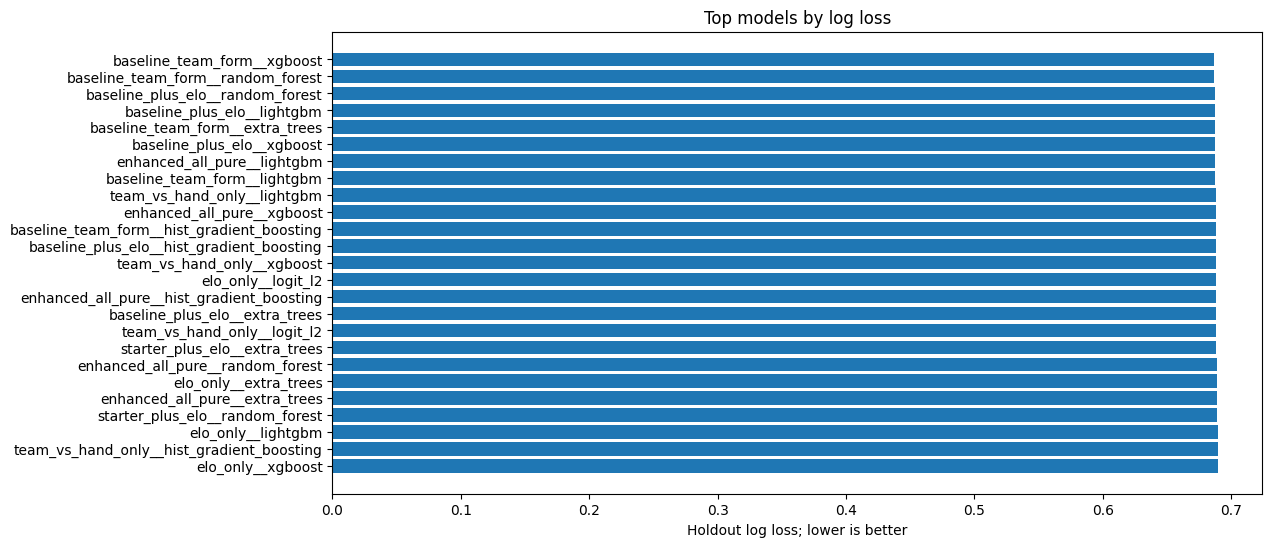

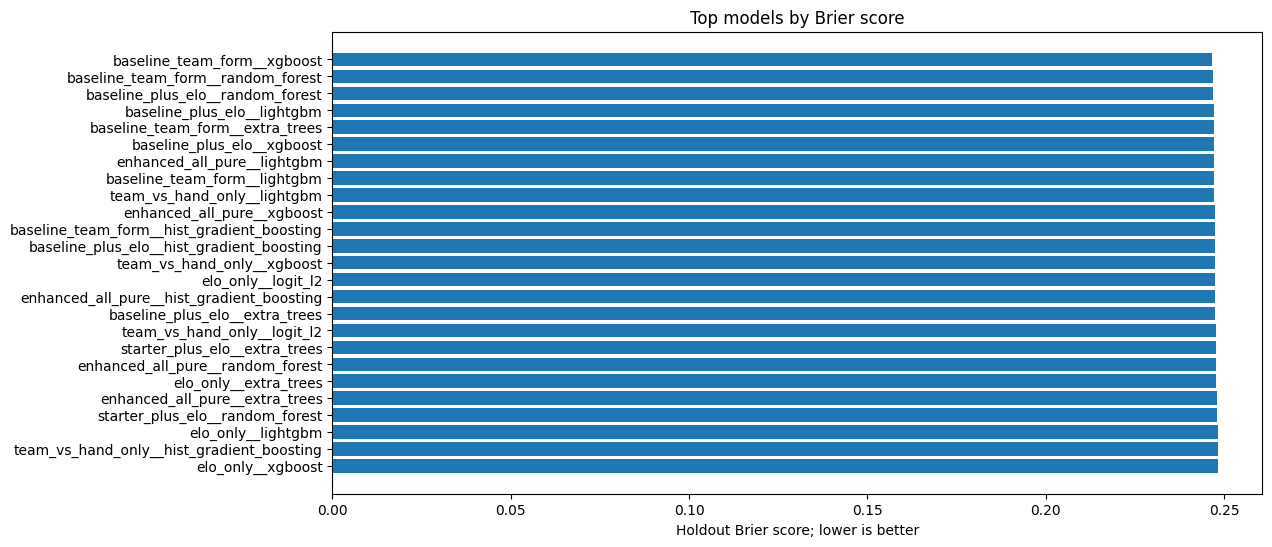

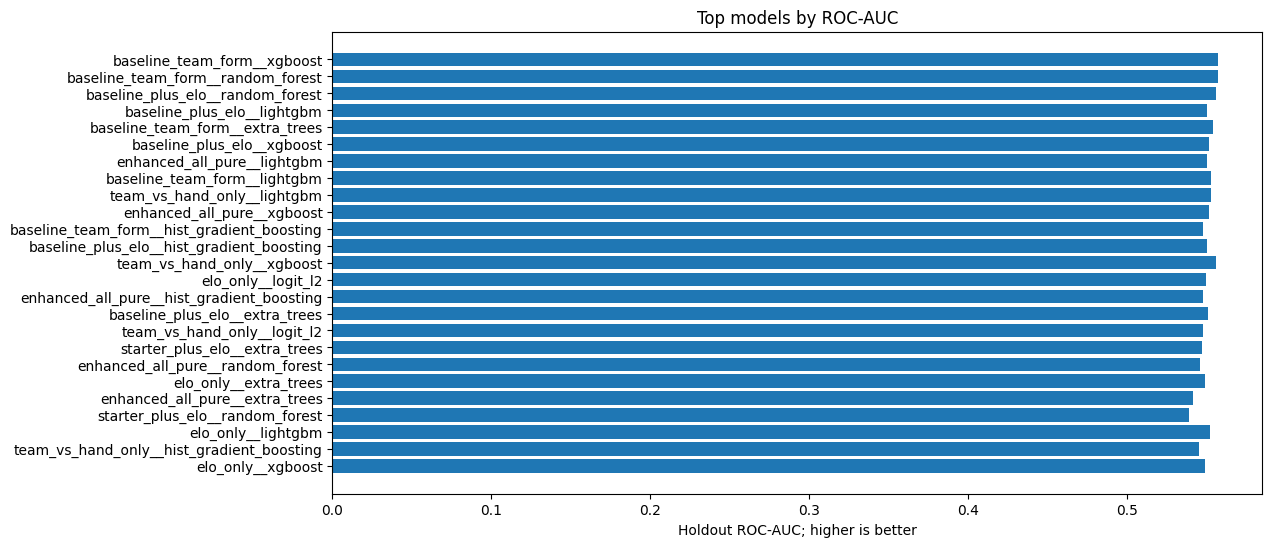

In [11]:
plot_df = results_df[~results_df["model_key"].str.contains("always_home|coin_flip", regex=True)].copy().head(25)

plt.figure(figsize=(12, 6))
plt.barh(plot_df["model_key"], plot_df["log_loss"])
plt.gca().invert_yaxis()
plt.xlabel("Holdout log loss; lower is better")
plt.title("Top models by log loss")
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(plot_df["model_key"], plot_df["brier"])
plt.gca().invert_yaxis()
plt.xlabel("Holdout Brier score; lower is better")
plt.title("Top models by Brier score")
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(plot_df["model_key"], plot_df["roc_auc"])
plt.gca().invert_yaxis()
plt.xlabel("Holdout ROC-AUC; higher is better")
plt.title("Top models by ROC-AUC")
plt.show()

## 11. Pick a diagnostic best model

This chooses the best model by log loss. You can override it manually.

In [12]:
model_rows = results_df[results_df["model_key"].isin(fitted_models.keys())].copy()
if model_rows.empty:
    raise ValueError("No fitted models available.")

BEST_MODEL_KEY = model_rows.sort_values(["log_loss", "brier", "roc_auc"], ascending=[True, True, False]).iloc[0]["model_key"]
# Manual override example:
# BEST_MODEL_KEY = "baseline_plus_elo__logit_l2"

best_info = fitted_models[BEST_MODEL_KEY]
best_prob = holdout_predictions[BEST_MODEL_KEY]

print("Best model:", BEST_MODEL_KEY)
print("Feature count:", len(best_info["feature_cols"]))
print("Metrics:", {k: best_info["metrics"][k] for k in ["log_loss", "brier", "accuracy_50pct", "avg_pred", "actual_rate", "roc_auc"]})
print("Best params:", best_info["metrics"].get("best_params", {}))

best_pred = (best_prob >= 0.5).astype(int)
print("Classification report:")
print(classification_report(y_holdout, best_pred, digits=3))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_holdout, best_pred), index=["actual_away", "actual_home"], columns=["pred_away", "pred_home"]))

Best model: baseline_team_form__xgboost
Feature count: 68
Metrics: {'log_loss': 0.6865522193955266, 'brier': 0.24673101615327384, 'accuracy_50pct': 0.54625, 'avg_pred': 0.5348836065083742, 'actual_rate': 0.525, 'roc_auc': 0.557359022556391}
Best params: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.02, 'model__max_depth': 2, 'model__min_child_weight': 20, 'model__n_estimators': 100, 'model__reg_alpha': 0.1, 'model__reg_lambda': 2.0, 'model__subsample': 0.8}
Classification report:
              precision    recall  f1-score   support

           0      0.547     0.258     0.351       380
           1      0.546     0.807     0.651       420

    accuracy                          0.546       800
   macro avg      0.547     0.533     0.501       800
weighted avg      0.547     0.546     0.508       800

Confusion matrix:


,pred_away,pred_home
actual_away,98,282
actual_home,81,339


## 12. Calibration buckets

For betting, calibration is often more important than raw classification accuracy.

,games,avg_pred_prob,actual_home_win_rate,calibration_error
prob_bucket,,,,
"(-0.001, 0.35]",0,NaN,NaN,NaN
"(0.35, 0.4]",1,0.399342,0.000000,-0.399342
"(0.4, 0.45]",28,0.435598,0.250000,-0.185598
"(0.45, 0.5]",150,0.481329,0.493333,0.012004
"(0.5, 0.55]",286,0.526346,0.534965,0.008619
"(0.55, 0.6]",288,0.566836,0.552083,-0.014753
"(0.6, 0.65]",41,0.618736,0.536585,-0.082150
"(0.65, 0.7]",6,0.659929,0.833333,0.173404
"(0.7, 1.0]",0,NaN,NaN,NaN


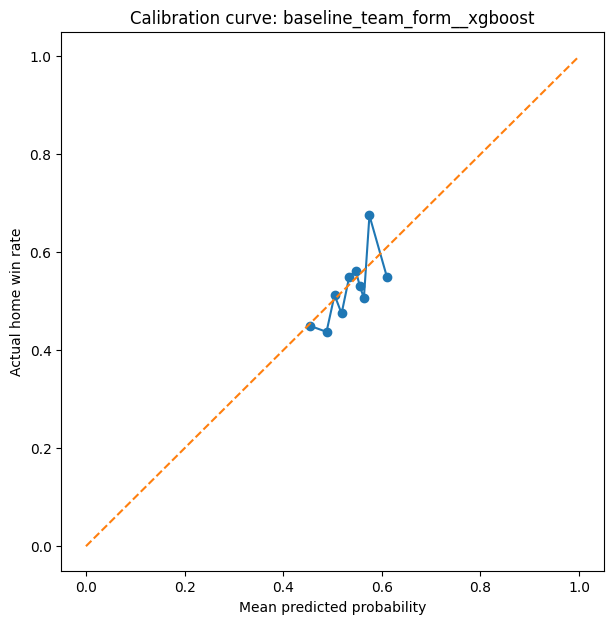

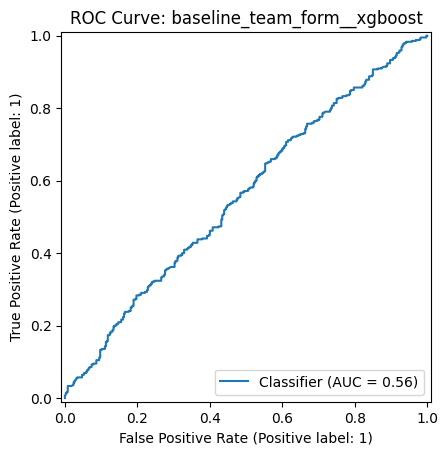

In [13]:
def calibration_table(y_true, prob, bins=None):
    if bins is None:
        bins = [0.0, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 1.0]
    df = pd.DataFrame({"y": np.asarray(y_true).astype(int), "p": np.asarray(prob).astype(float)})
    df["prob_bucket"] = pd.cut(df["p"], bins=bins, include_lowest=True)
    return df.groupby("prob_bucket", observed=False).agg(
        games=("y", "size"),
        avg_pred_prob=("p", "mean"),
        actual_home_win_rate=("y", "mean"),
    ).assign(
        calibration_error=lambda x: x["actual_home_win_rate"] - x["avg_pred_prob"]
    )

cal_tbl = calibration_table(y_holdout, best_prob)
display(cal_tbl)

fraction_of_positives, mean_predicted_value = calibration_curve(y_holdout, best_prob, n_bins=10, strategy="quantile")
plt.figure(figsize=(7, 7))
plt.plot(mean_predicted_value, fraction_of_positives, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual home win rate")
plt.title(f"Calibration curve: {BEST_MODEL_KEY}")
plt.show()

RocCurveDisplay.from_predictions(y_holdout, best_prob)
plt.title(f"ROC Curve: {BEST_MODEL_KEY}")
plt.show()

## 13. Compare raw vs calibrated probabilities for the best model

This tests sigmoid and isotonic calibration. Promote the calibrated model only if it improves log loss/Brier and calibration.

In [ ]:
RUN_CALIBRATION_TEST = True

if RUN_CALIBRATION_TEST:
    feature_cols = best_info["feature_cols"]
    X_train = train_df[feature_cols]
    X_holdout = holdout_df[feature_cols]
    base_estimator = best_info["estimator"]

    calibration_rows = []
    calibration_models = {}
    calibration_probs = {}

    calibration_rows.append(evaluate_probabilities(y_holdout, best_prob, BEST_MODEL_KEY + "__raw", best_info["feature_set"], best_info["model_name"]))
    calibration_models[BEST_MODEL_KEY + "__raw"] = base_estimator
    calibration_probs[BEST_MODEL_KEY + "__raw"] = best_prob

    for method in ["sigmoid", "isotonic"]:
        print("Calibrating with", method)
        try:
            calibrated = CalibratedClassifierCV(
                estimator=clone(base_estimator),
                method=method,
                cv=TimeSeriesSplit(n_splits=3),
            )
            calibrated.fit(X_train, y_train)
            cal_prob = calibrated.predict_proba(X_holdout)[:, 1]
            key = BEST_MODEL_KEY + f"__calibrated_{method}"
            calibration_rows.append(evaluate_probabilities(y_holdout, cal_prob, key, best_info["feature_set"], best_info["model_name"]))
            calibration_models[key] = calibrated
            calibration_probs[key] = cal_prob
        except Exception as e:
            print("Calibration failed", method, repr(e))

    calibration_results = pd.DataFrame(calibration_rows).sort_values(["log_loss", "brier"])
    display(calibration_results[["model_key", "log_loss", "brier", "roc_auc", "accuracy_50pct", "avg_pred", "actual_rate"]])

    CALIBRATED_BEST_KEY = calibration_results.iloc[0]["model_key"]
    print("Best calibrated/raw candidate:", CALIBRATED_BEST_KEY)
else:
    CALIBRATED_BEST_KEY = BEST_MODEL_KEY + "__raw"

## 14. Feature importance for selected model

Permutation importance is model-agnostic and often more meaningful than built-in tree importance.

In [ ]:
if RUN_PERMUTATION_IMPORTANCE:
    selected_key = BEST_MODEL_KEY
    selected_info = fitted_models[selected_key]
    selected_estimator = selected_info["estimator"]
    selected_cols = selected_info["feature_cols"]
    X_holdout = holdout_df[selected_cols]

    print("Running permutation importance for", selected_key)
    perm = permutation_importance(
        selected_estimator,
        X_holdout,
        y_holdout,
        scoring="neg_log_loss",
        n_repeats=PERMUTATION_IMPORTANCE_REPEATS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    importance_df = pd.DataFrame({
        "feature": selected_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    display(importance_df.head(40))

    top = importance_df.head(25).iloc[::-1]
    plt.figure(figsize=(10, 8))
    plt.barh(top["feature"], top["importance_mean"])
    plt.xlabel("Permutation importance; higher is better")
    plt.title(f"Top features: {selected_key}")
    plt.show()
else:
    print("Permutation importance skipped.")

## 15. Edge tuning when historical odds are available

This will only be useful once `market_home_no_vig_prob`, moneyline prices, and completed-game outcomes overlap historically. Until then, it will skip gracefully.

In [ ]:
def american_to_decimal(american):
    american = float(american)
    if american > 0:
        return 1 + american / 100
    return 1 + 100 / abs(american)

def unit_profit_if_win(american):
    return american_to_decimal(american) - 1

def evaluate_edge_thresholds(frame, prob, thresholds=np.arange(0.00, 0.101, 0.005)):
    required = ["market_home_no_vig_prob", "market_away_no_vig_prob", "home_moneyline_median", "away_moneyline_median", TARGET_COL]
    missing = [c for c in required if c not in frame.columns]
    if missing:
        print("Missing odds/eval columns:", missing)
        return pd.DataFrame()

    df = frame[required].copy()
    df["model_home_prob"] = prob
    df["model_away_prob"] = 1 - df["model_home_prob"]
    df = df.dropna(subset=required + ["model_home_prob"])
    if df.empty:
        print("No completed games with odds available for edge tuning.")
        return pd.DataFrame()

    rows = []
    for t in thresholds:
        bets = []
        for _, r in df.iterrows():
            home_edge = r["model_home_prob"] - r["market_home_no_vig_prob"]
            away_edge = r["model_away_prob"] - r["market_away_no_vig_prob"]

            if home_edge >= t and home_edge >= away_edge:
                won = int(r[TARGET_COL] == 1)
                price = r["home_moneyline_median"]
                profit = unit_profit_if_win(price) if won else -1.0
                bets.append(("home", home_edge, price, won, profit))
            elif away_edge >= t:
                won = int(r[TARGET_COL] == 0)
                price = r["away_moneyline_median"]
                profit = unit_profit_if_win(price) if won else -1.0
                bets.append(("away", away_edge, price, won, profit))

        if bets:
            b = pd.DataFrame(bets, columns=["side", "edge", "price", "won", "profit"])
            rows.append({
                "edge_threshold": t,
                "bets": len(b),
                "win_rate": b["won"].mean(),
                "avg_edge": b["edge"].mean(),
                "roi_per_unit": b["profit"].sum() / len(b),
                "profit_units": b["profit"].sum(),
                "avg_price": b["price"].mean(),
            })
        else:
            rows.append({"edge_threshold": t, "bets": 0, "win_rate": np.nan, "avg_edge": np.nan, "roi_per_unit": np.nan, "profit_units": 0.0, "avg_price": np.nan})
    return pd.DataFrame(rows)

edge_results = evaluate_edge_thresholds(holdout_df, best_prob)
if not edge_results.empty:
    display(edge_results.sort_values(["roi_per_unit", "bets"], ascending=[False, False]).head(20))
    plt.figure(figsize=(10, 5))
    plt.plot(edge_results["edge_threshold"], edge_results["roi_per_unit"], marker="o")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Minimum edge threshold")
    plt.ylabel("ROI per unit")
    plt.title("Historical edge threshold tuning")
    plt.show()

## 16. Manual champion export

Use this only after you are comfortable with the model, calibration, and benchmarks.

Set `APPROVE_EXPORT = True` and choose the `MODEL_TO_EXPORT_KEY`.

This writes:

```text
models/mlb_moneyline_champion.joblib
models/mlb_moneyline_champion_metadata.json
```

Your GitHub Action can then load the champion model for daily scoring.

In [ ]:
APPROVE_EXPORT = False
MODEL_TO_EXPORT_KEY = BEST_MODEL_KEY
# If the calibrated model won and you want to export it, set a custom estimator below.
# MODEL_TO_EXPORT_KEY = CALIBRATED_BEST_KEY

CHAMPION_NOTES = "Manual champion selected from diagnostic notebook after benchmark, calibration, and feature-set review."

def export_champion_model(model_key, estimator, feature_cols, metrics, model_family, feature_set_name, notes=""):
    created_at = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

    champion_path = MODEL_DIR / "mlb_moneyline_champion.joblib"
    metadata_path = MODEL_DIR / "mlb_moneyline_champion_metadata.json"
    archive_dir = MODEL_DIR / "archive"
    archive_dir.mkdir(parents=True, exist_ok=True)

    archive_path = archive_dir / f"mlb_moneyline_{model_family}_{timestamp}.joblib"
    archive_metadata_path = archive_dir / f"mlb_moneyline_{model_family}_{timestamp}_metadata.json"

    metadata = {
        "model_name": "mlb_moneyline_champion",
        "source_model_key": model_key,
        "model_family": model_family,
        "feature_set_name": feature_set_name,
        "target_col": TARGET_COL,
        "feature_count": len(feature_cols),
        "feature_cols": list(feature_cols),
        "metrics": metrics,
        "notes": notes,
        "created_at_utc": created_at,
    }

    bundle = {
        "model_name": "mlb_moneyline_champion",
        "estimator": estimator,
        "feature_cols": list(feature_cols),
        "target_col": TARGET_COL,
        "model_family": model_family,
        "feature_set_name": feature_set_name,
        "metrics": metrics,
        "metadata": metadata,
        "created_at_utc": created_at,
    }

    joblib.dump(bundle, champion_path)
    joblib.dump(bundle, archive_path)
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    archive_metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print("Saved champion model:", champion_path)
    print("Saved champion metadata:", metadata_path)
    print("Saved archive model:", archive_path)

    return champion_path, metadata_path

if APPROVE_EXPORT:
    if MODEL_TO_EXPORT_KEY in fitted_models:
        info = fitted_models[MODEL_TO_EXPORT_KEY]
        export_champion_model(
            model_key=MODEL_TO_EXPORT_KEY,
            estimator=info["estimator"],
            feature_cols=info["feature_cols"],
            metrics={k: info["metrics"][k] for k in ["log_loss", "brier", "accuracy_50pct", "avg_pred", "actual_rate", "roc_auc"]},
            model_family=info["model_name"],
            feature_set_name=info["feature_set"],
            notes=CHAMPION_NOTES,
        )
    else:
        raise ValueError(f"MODEL_TO_EXPORT_KEY is not in fitted_models: {MODEL_TO_EXPORT_KEY}")
else:
    print("APPROVE_EXPORT is False. No model exported.")
    print("Current diagnostic best model:", BEST_MODEL_KEY)

## 17. Interpretation checklist

Before exporting a champion model, answer these:

1. Does it beat `train_home_rate_constant` on log loss and Brier?
2. Does it beat raw Elo if `elo_home_win_prob` exists?
3. Is AUC meaningfully above 0.50?
4. Is calibration reasonable in the 0.45–0.60 probability range where most MLB games live?
5. Is the model not simply predicting home team on nearly every game?
6. Do feature importances make baseball sense?
7. If historical odds exist, does edge tuning show positive signal after costs/vig?

Do not promote a model only because it has the highest accuracy.